# PokerBench preflop EDA

Exploratory pass over the [`RZ412/PokerBench`](https://huggingface.co/datasets/RZ412/PokerBench) preflop split:

- action-label distribution (raw and canonicalised)
- hero-position balance
- pot size / stack-depth profile
- action-sequence complexity (openers, 3-bet, 4-bet, squeezes)
- top hand-classes and how their action-mix moves with position

The notebook downloads the train split (default: 5 000 rows) via `huggingface_hub` and reuses the on-disk HF cache on subsequent runs, so re-running is cheap.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'poker_predictor').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

print('repo root :', REPO_ROOT)
print('pandas    :', pd.__version__)
print('numpy     :', np.__version__)

repo root : /Users/morningstar/Desktop/Cold_Storage/Agent_Officespace
pandas    : 2.3.3
numpy     : 2.5.0


In [2]:
from poker_predictor.data.loaders import load_pokerbench_preflop, samples_to_dataframe
from poker_predictor.features.build import canonical_action_label

SAMPLE_LIMIT = int(os.environ.get('POKERBENCH_LIMIT', '5000'))
print(f'loading {SAMPLE_LIMIT} preflop samples from PokerBench (train) ...')
samples = load_pokerbench_preflop(split='train', limit=SAMPLE_LIMIT)
print(f'  -> {len(samples)} samples loaded')

df = samples_to_dataframe(samples)
df['canonical_decision'] = df['correct_decision'].map(canonical_action_label)
df['n_available_moves'] = df['available_moves'].fillna('').apply(
    lambda s: len([m for m in s.split(',') if m])
)
df.head()

loading 5000 preflop samples from PokerBench (train) ...


/Users/morningstar/Desktop/Cold_Storage/Agent_Officespace/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  -> 5000 samples loaded


,hero_pos,hero_hole,hero_stack_bb,num_players,pot_bb,num_bets,facing_bet_bb,n_events,available_moves,correct_decision,canonical_decision,n_available_moves
0,HJ,AhKc,100.0,4,115.5,3,6.5,4,"call,fold",fold,fold,2
1,SB,AsAc,100.0,4,142.0,4,20.0,6,"call,fold",call,call,2
2,BTN,KhJh,100.0,4,38.0,3,24.0,6,"allin,call,fold",fold,fold,3
3,BB,AsAh,100.0,4,18.1,2,12.5,3,"allin,27.0bb,call,fold",27.0bb,raise,4
4,CO,JhJd,100.0,5,136.5,4,23.0,6,fold,fold,fold,1


In [3]:
raw_counts = df['correct_decision'].value_counts()
canonical_counts = df['canonical_decision'].value_counts(dropna=False)

print(f'unique raw decision strings : {raw_counts.size}')
print(f'unique canonical labels     : {canonical_counts.dropna().size}')
print(f'rows with unknown label     : {int(canonical_counts.get(np.nan, 0))}')

canonical_share = (
    df['canonical_decision']
    .dropna()
    .value_counts(normalize=True)
    .rename('share')
    .to_frame()
)
canonical_share['count'] = df['canonical_decision'].dropna().value_counts()
canonical_share.round(3)

unique raw decision strings : 54
unique canonical labels     : 4
rows with unknown label     : 0


,share,count
canonical_decision,,
fold,0.482,2411
call,0.392,1961
raise,0.121,607
check,0.004,21


/var/folders/fv/7353h_0d5jzfv61r_mhb5_f40000gn/T/ipykernel_71763/2063381012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


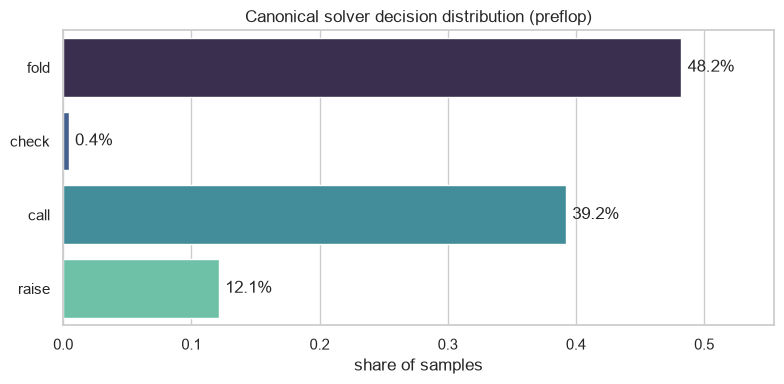

In [4]:
order = ['fold', 'check', 'call', 'raise', 'allin']
order = [a for a in order if a in canonical_share.index]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=canonical_share.loc[order, 'share'].values,
    y=order,
    ax=ax,
    palette='mako',
)
for i, v in enumerate(canonical_share.loc[order, 'share'].values):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center')
ax.set_xlabel('share of samples')
ax.set_title('Canonical solver decision distribution (preflop)')
ax.set_xlim(0, max(canonical_share['share']) * 1.15)
plt.tight_layout()
plt.show()

In [5]:
position_order = ['UTG', 'HJ', 'CO', 'BTN', 'SB', 'BB']
pos_mix = (
    df.dropna(subset=['canonical_decision'])
      .groupby('hero_pos')['canonical_decision']
      .value_counts(normalize=True)
      .unstack()
      .reindex(position_order)
      .fillna(0.0)
)

col_order = [c for c in order if c in pos_mix.columns]
pos_mix[col_order].round(3)

canonical_decision,fold,check,call,raise
hero_pos,,,,
UTG,0.524,0.000,0.361,0.114
HJ,0.541,0.000,0.353,0.106
CO,0.586,0.000,0.284,0.130
BTN,0.548,0.000,0.318,0.134
SB,0.468,0.000,0.406,0.126
BB,0.405,0.012,0.468,0.115


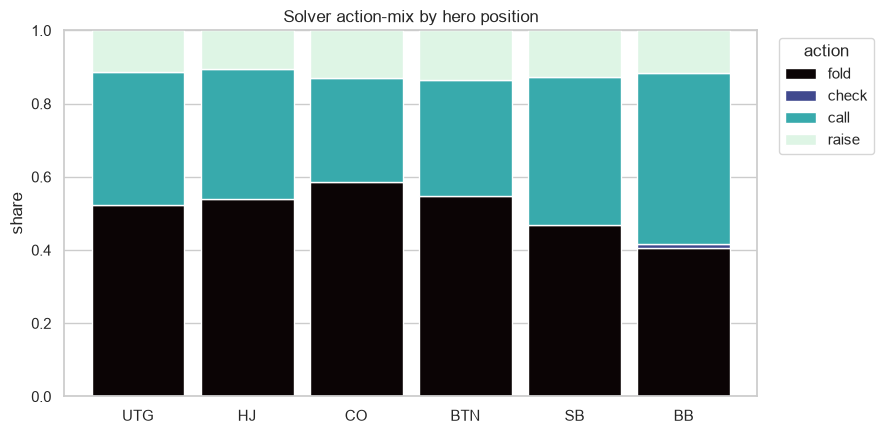

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pos_mix[col_order].plot(kind='bar', stacked=True, ax=ax, colormap='mako', width=0.85)
ax.set_title('Solver action-mix by hero position')
ax.set_ylabel('share')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.legend(title='action', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
profile = pd.DataFrame(
    {
        'pot_bb': df['pot_bb'],
        'facing_bet_bb': df['facing_bet_bb'],
        'num_events': df['n_events'],
        'num_bets': df['num_bets'],
        'num_players': df['num_players'],
    }
).describe(percentiles=[0.1, 0.5, 0.9]).T
profile.round(2)

,count,mean,std,min,10%,50%,90%,max
pot_bb,5000.0,82.86,55.98,1.0,5.0,104.5,147.0,220.0
facing_bet_bb,5000.0,14.01,10.16,0.0,2.0,14.0,29.0,41.0
num_events,5000.0,4.41,2.39,0.0,1.0,4.0,8.0,12.0
num_bets,5000.0,2.68,1.16,0.0,1.0,3.0,4.0,5.0
num_players,5000.0,3.43,1.03,1.0,2.0,4.0,5.0,6.0


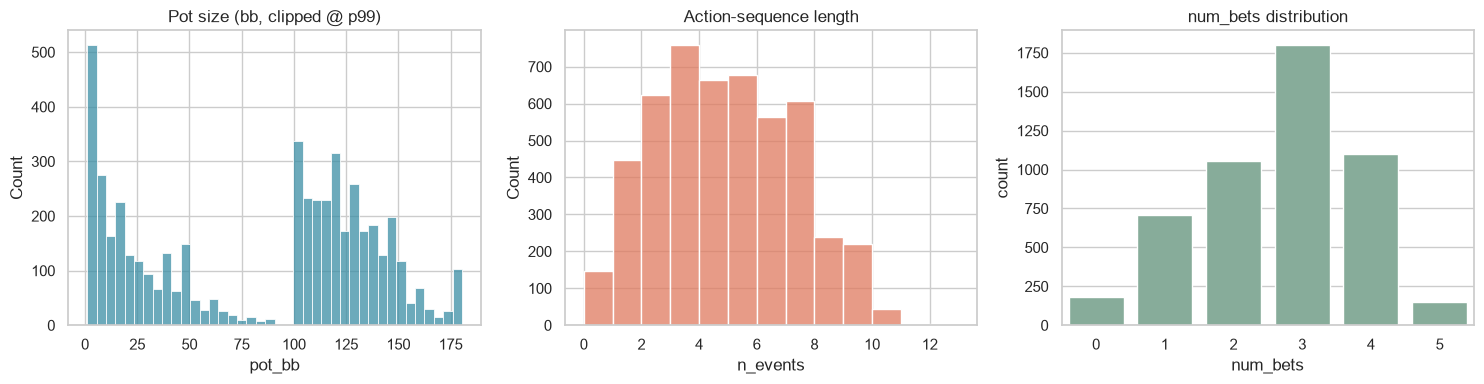

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['pot_bb'].clip(upper=df['pot_bb'].quantile(0.99)), bins=40, ax=axes[0], color='#3b8ea5')
axes[0].set_title('Pot size (bb, clipped @ p99)')
sns.histplot(df['n_events'], bins=range(0, df['n_events'].max() + 2), ax=axes[1], color='#e07a5f')
axes[1].set_title('Action-sequence length')
sns.countplot(x='num_bets', data=df, ax=axes[2], color='#81b29a')
axes[2].set_title('num_bets distribution')
plt.tight_layout()
plt.show()

In [9]:
from poker_predictor.features.cards import hand_class

df['hand_class'] = df['hero_hole'].apply(hand_class)
top_hands = df['hand_class'].value_counts().head(20)
print('top-20 hand classes:')
print(top_hands)

hand_action = (
    df.dropna(subset=['canonical_decision'])
      .groupby('hand_class')['canonical_decision']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0.0)
)
for a in col_order:
    if a not in hand_action.columns:
        hand_action[a] = 0.0
hand_action = hand_action[col_order]

premium = ['AA', 'KK', 'QQ', 'JJ', 'AKs', 'AKo', 'AQs', '72o', '32o', '82o']
hand_action.loc[[h for h in premium if h in hand_action.index]].round(3)

top-20 hand classes:
hand_class
AA     513
AKo    369
KK     353
QQ     328
JJ     215
AQo    188
AKs    144
KQo    138
TT     129
AQs    111
99      97
KQs     92
AJo     80
KJs     79
AJs     73
88      70
66      67
A5s     64
QJs     61
KJo     60
Name: count, dtype: int64


canonical_decision,fold,check,call,raise
hand_class,,,,
AA,0.025,0.0,0.858,0.117
KK,0.048,0.0,0.822,0.130
QQ,0.113,0.0,0.793,0.095
JJ,0.284,0.0,0.586,0.130
AKs,0.132,0.0,0.736,0.132
AKo,0.298,0.0,0.572,0.130
AQs,0.243,0.0,0.586,0.171


## Takeaways

- The canonical label distribution is dominated by `fold` (as expected preflop — most spots are “no hand, no position”).
- Late-position rows (`BTN`, `CO`) shift decisively toward `raise` / `call`; early-position rows toward `fold`.
- Premium classes (`AA`, `KK`, `AKs`) are near-100% `raise` regardless of position; trash hands (`72o`, `32o`) are near-100% `fold`.
- Pot sizes are strongly right-skewed (a small number of 4-bet / all-in pots dominate the tail), which motivates the log-transform / clipping used by the classical baseline.